<a href="https://colab.research.google.com/github/VakeesanM/DL-Learning-Deliverables/blob/main/Week%209%20-%20GAN/DCGAN_and_WGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import time

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 30
device

'cuda'

In [ ]:
data = datasets.FashionMNIST(root="./data", transform=ToTensor(), download=True)
len(data)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.95MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 29.5MB/s]


60000

(<matplotlib.image.AxesImage at 0x7f5d830753d0>, torch.Size([1, 28, 28]))

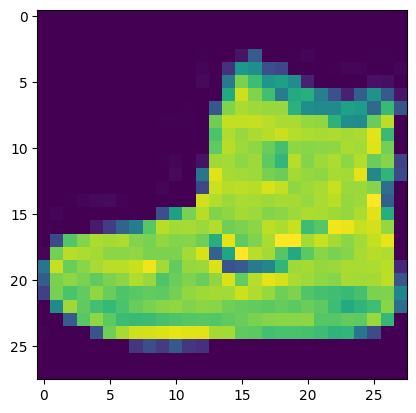

In [ ]:
image, _ = next(iter(data))
plt.imshow(image.squeeze()), image.shape

In [ ]:
class Generator(nn.Module):
  def __init__(self, z_dim, img_dim):
    super(Generator, self).__init__()
    self.seq = nn.Sequential(
        nn.Linear(in_features=z_dim, out_features=256),
        nn.LeakyReLU(0.1),
        nn.Linear(in_features=256, out_features=img_dim),
        nn.Tanh()
    )
  def forward(self, x):
    return self.seq(x)

class Discriminator(nn.Module):
  def __init__(self, img_dim):
    super(Discriminator, self).__init__()
    self.seq = nn.Sequential(
        nn.Linear(in_features=img_dim, out_features=128),
        nn.LeakyReLU(0.1),
        nn.Linear(in_features=128, out_features=1),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.seq(x)

In [ ]:
lr = 3e-4 # An Hyperparameter that I can test out
z_dim = 64 # An Hyperparameter that I can test out
img_dim = 28*28 # This is the size of the FashionMist images
batch_size = 50

In [ ]:
disc = Discriminator(img_dim).to(device)
gen = Generator(z_dim, img_dim).to(device)
set_noise = torch.randn((batch_size, z_dim)).to(device)

In [ ]:
optim_disc = torch.optim.Adam(disc.parameters(), lr=lr)
optim_gen = torch.optim.Adam(gen.parameters(), lr=lr)
loss_fn = nn.BCELoss()

In [ ]:
loader = DataLoader(data, shuffle=True, batch_size=batch_size)
len(loader)

1200

In [ ]:
gen_loss = []
disc_loss = []
start = time.time()
for epoch in range(EPOCHS):
  total_disc_loss = 0
  total_gen_loss = 0

  for batch_indx, (real, _) in enumerate(loader):
    real = real.view(-1, img_dim).to(device)
    real_batch_size = real.shape[0]


    #Disc Training
    noise = torch.randn(real_batch_size, z_dim).to(device)
    fake = gen(noise)

    disc_real = disc(real).view(-1)
    lossD_real = loss_fn(disc_real, torch.ones_like(disc_real))

    disc_fake = disc(fake.detach()).view(-1)
    lossD_fake = loss_fn(disc_fake, torch.zeros_like(disc_fake))

    lossD = (lossD_real + lossD_fake) / 2

    optim_disc.zero_grad()
    lossD.backward()
    optim_disc.step()
    total_disc_loss += lossD.item()
    #Gen Training

    output = disc(fake).view(-1)
    lossG = loss_fn(output, torch.ones_like(output))
    optim_gen.zero_grad()
    lossG.backward()
    optim_gen.step()
    total_gen_loss += lossG.item()
  gen_loss.append(total_gen_loss/batch_size)
  disc_loss.append(total_disc_loss/batch_size)
  print(f"Epoch: {epoch+1} | Generator Train Loss: {gen_loss[-1]:.4f} | Discriminator Train Loss| {disc_loss[-1]:.4f}")
finish = time.time()
minute = (finish - start) // 60
seconds = (finish - start) % 60
print(f"Training for {EPOCHS} epochs took {minute} Minutes and {seconds} seconds")


Epoch: 1 | Generator Train Loss: 27.1004 | Discriminator Train Loss| 11.6609
Epoch: 2 | Generator Train Loss: 23.9563 | Discriminator Train Loss| 13.7975
Epoch: 3 | Generator Train Loss: 21.5235 | Discriminator Train Loss| 15.3982
Epoch: 4 | Generator Train Loss: 20.7004 | Discriminator Train Loss| 15.5601
Epoch: 5 | Generator Train Loss: 21.9509 | Discriminator Train Loss| 14.8151
Epoch: 6 | Generator Train Loss: 22.7873 | Discriminator Train Loss| 14.9392
Epoch: 7 | Generator Train Loss: 23.7429 | Discriminator Train Loss| 14.3950
Epoch: 8 | Generator Train Loss: 25.7341 | Discriminator Train Loss| 14.1541
Epoch: 9 | Generator Train Loss: 24.8794 | Discriminator Train Loss| 14.0807
Epoch: 10 | Generator Train Loss: 24.5048 | Discriminator Train Loss| 14.7954
Epoch: 11 | Generator Train Loss: 24.7567 | Discriminator Train Loss| 14.4841
Epoch: 12 | Generator Train Loss: 25.7153 | Discriminator Train Loss| 14.4129
Epoch: 13 | Generator Train Loss: 24.9704 | Discriminator Train Loss| 14.

/tmp/ipykernel_5047/4166190105.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plt.imshow(torch.tensor(test).cpu())


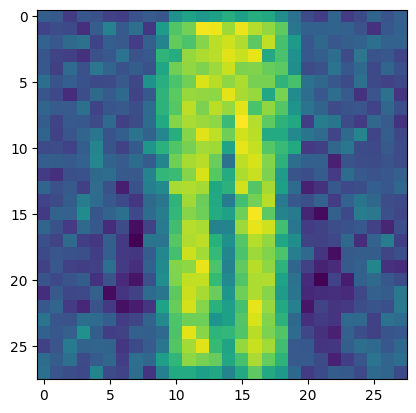

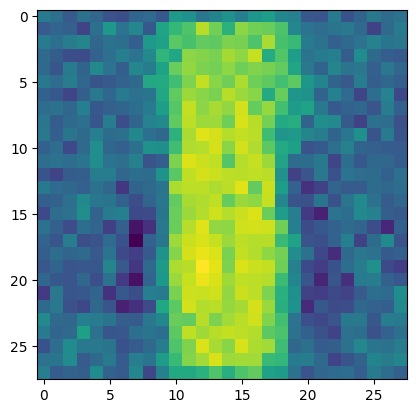

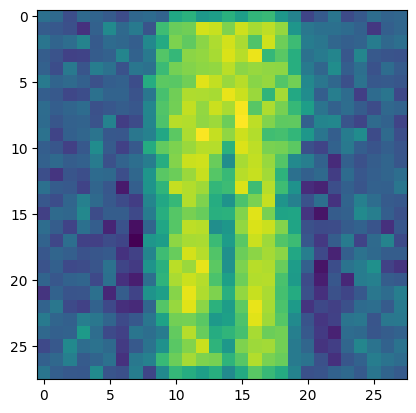

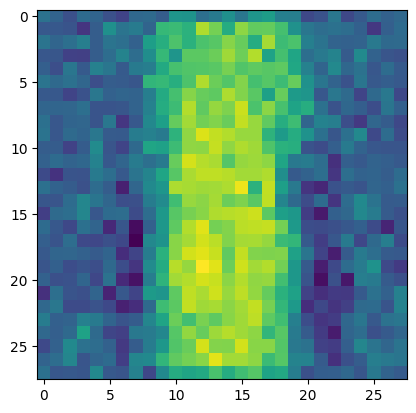

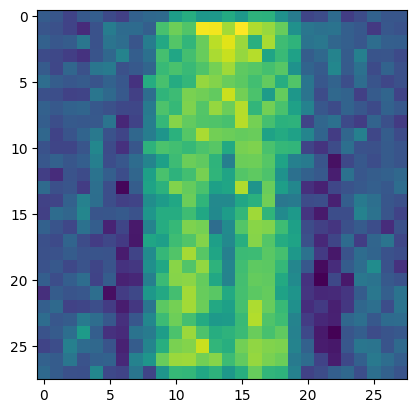

In [ ]:
for i in range(5):
  test = gen(torch.rand(z_dim).to(device)).reshape(28,28)
  plt.imshow(torch.tensor(test).cpu())
  plt.show()

If you squint hard enough, a few of them do look like pants. Its obvious that my model experienced mode collapse.

I am going to try to implement WGAN now.

In [ ]:
class DiscriminatorV2(nn.Module):
  def __init__(self, img_dim):
    super(DiscriminatorV2, self).__init__()
    self.seq = nn.Sequential(
        nn.Linear(in_features=img_dim, out_features=128),
        nn.LeakyReLU(0.1),
        nn.Linear(in_features=128, out_features=1)
    )

  def forward(self, x):
    return self.seq(x)

In [ ]:
lr = 5e-5 # An Hyperparameter that I can test out
z_dim = 64 # An Hyperparameter that I can test out
img_dim = 28*28 # This is the size of the FashionMist images
critic_iters = 5
weight_clip = 0.01

Wdisc = DiscriminatorV2(img_dim).to(device)
Wgen = Generator(z_dim, img_dim).to(device)
set_noise = torch.randn((batch_size, z_dim)).to(device)

W_optim_disc = torch.optim.RMSprop(Wdisc.parameters(), lr=lr)
W_optim_gen = torch.optim.RMSprop(Wgen.parameters(), lr=lr)

Wdisc.train()
Wgen.train()

Generator(
  (seq): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Tanh()
  )
)

In [ ]:
start = time.time()
for epoch in range(5):

  for batch_indx, (real, _) in enumerate(loader):
    real = real.view(-1, img_dim).to(device)
    real_batch_size = real.shape[0]

    for _ in range(critic_iters):
    #Disc Training
      noise = torch.randn(real_batch_size, z_dim).to(device)
      fake = Wgen(noise)

      disc_real = Wdisc(real).view(-1)
      disc_fake = Wdisc(fake.detach()).view(-1)

      loss_disc = -(torch.mean(disc_real) - torch.mean(disc_fake))
      W_optim_disc.zero_grad()
      loss_disc.backward(retain_graph=True)
      W_optim_disc.step()

      for p in Wdisc.parameters():
        p.data.clamp_(-weight_clip, weight_clip)
    #Gen Training

    output = Wdisc(fake).view(-1)
    lossG = -torch.mean(output)
    W_optim_gen.zero_grad()
    lossG.backward()
    W_optim_gen.step()
  print(f"Reached Epoch: {epoch+1}")
finish = time.time()
minute = (finish - start) // 60
seconds = (finish - start) % 60
print(f"Training for {EPOCHS} epochs took {minute} Minutes and {seconds} seconds")


Reached Epoch: 1
Reached Epoch: 2
Reached Epoch: 3
Reached Epoch: 4
Reached Epoch: 5
Training for 30 epochs took 1.0 Minutes and 39.52548170089722 seconds


/tmp/ipykernel_5047/348596721.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plt.imshow(torch.tensor(test).cpu())


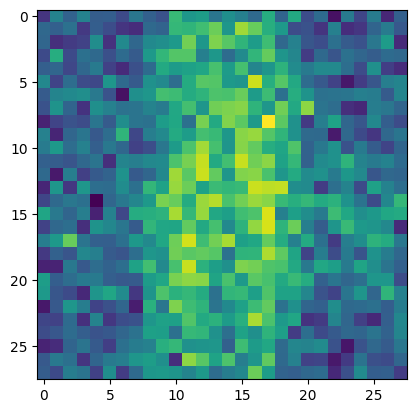

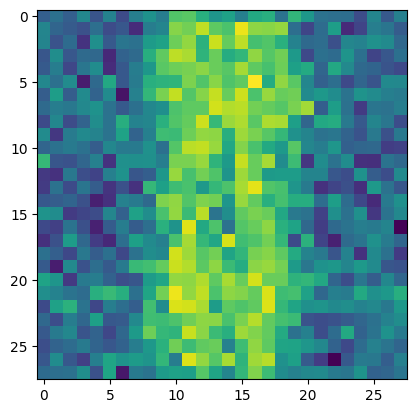

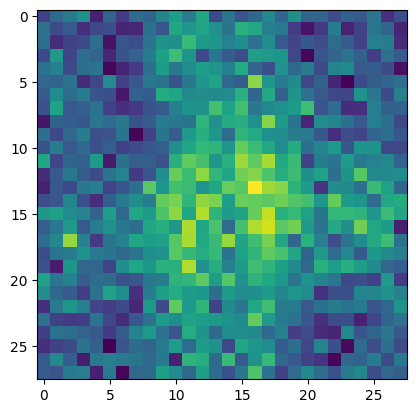

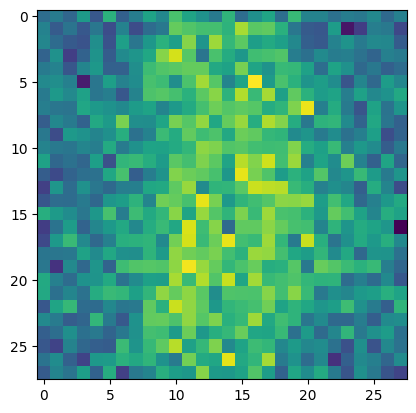

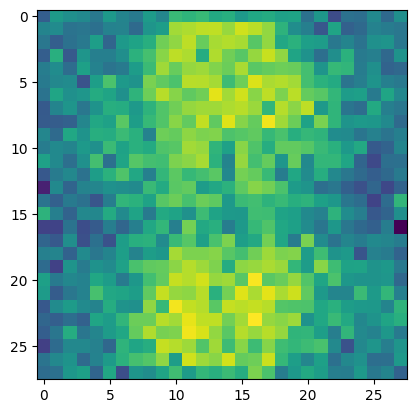

In [ ]:
for i in range(5):
  test = Wgen(torch.rand(z_dim).to(device)).reshape(28,28)
  plt.imshow(torch.tensor(test).cpu())
  plt.show()